In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class RidgeRegression:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        n_features = X.shape[1]
        X_b = np.c_[np.ones((len(X), 1)), X]
        I = np.eye(n_features + 1)
        I[0, 0] = 0 
        
        # Normal Equation with L2 penalty
        theta = np.linalg.inv(X_b.T.dot(X_b) + self.alpha * I).dot(X_b.T).dot(y)
        self.bias = theta[0]
        self.weights = theta[1:]

In [3]:
if __name__ == "__main__":
    # 1. Load Data
    df = pd.read_csv('laptop_prices.csv')
    csv_columns = ['cpu_cores', 'ram_gb', 'gpu_memory_gb', 'sticker_count']
    X_data = df[csv_columns].values 
    y_data = df['price_usd'].values
    feature_names = ['CPU', 'RAM', 'GPU', 'Stickers']
    alphas = np.logspace(-1, 5, 100)

    weights_history = []

    for a in alphas:
        model = RidgeRegression(alpha=a)
        model.fit(X_data, y_data)
        weights_history.append(model.weights)
        

    weights_history = np.array(weights_history)

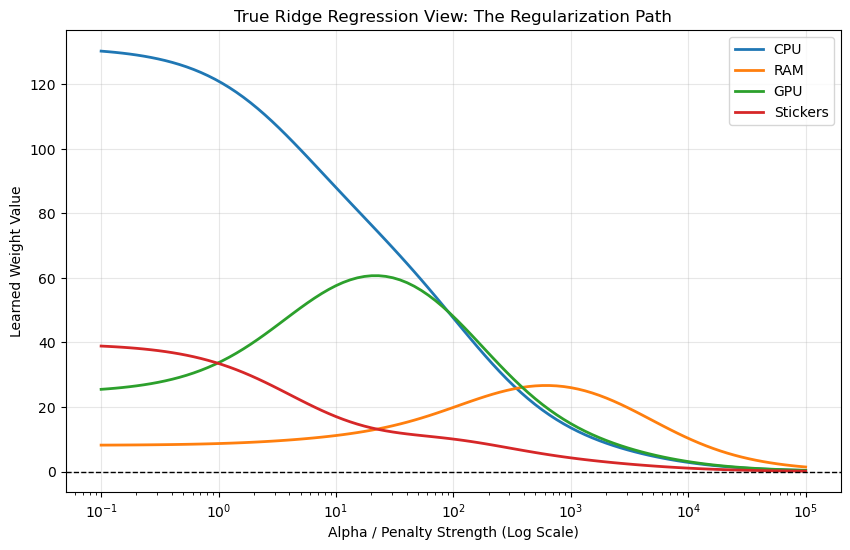

In [4]:
    plt.figure(figsize=(10, 6))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i in range(len(feature_names)):
        plt.plot(alphas, weights_history[:, i], label=feature_names[i], color=colors[i], linewidth=2)

    # We use a logarithmic scale for the X-axis because alpha grows exponentially
    plt.xscale('log')
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    
    plt.title('True Ridge Regression View: The Regularization Path')
    plt.xlabel('Alpha / Penalty Strength (Log Scale)')
    plt.ylabel('Learned Weight Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()